#Veri Hazırlığı ve Ön İşleme

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
from scipy import stats

!pip install pingouin -q
import pingouin as pg

warnings.filterwarnings('ignore')

# 1.1. Veri Setinin Yüklenmesi
df = pd.read_csv('sans-oyunlari.csv')

# 1.2. Kategorik Değişkenlerin Sayısallaştırılması

# Şans Oyunları Oynama Sıklığı
siklik_esleme = {
    "Ayda 1'den az / Çok nadir": 1,
    "Ayda 1-3 kez": 2,
    "Haftada 1 kez": 3,
    "Haftada birkaç kez": 4,
    "Her gün": 5
}
df['oyun_sikligi'] = df['Şans oyunlarını ne sıklıkla oynarsınız?'].map(siklik_esleme)

# Tahmini Toplam Kazanç Miktarı
kazanc_esleme = {
    "0 - 1.000 TL": 1,
    "1.001 - 5.000 TL": 2,
    "5.001 - 15.000 TL": 3,
    "15.001 - 30.000 TL": 4,
    "30.000 TL üzeri": 5
}
df['kazanc_miktari'] = df['Şans oyunlarından (son 6-12 ay içerisindeki) tahmini toplam kazanç miktarınız hangi aralıktadır?\n'].map(kazanc_esleme)

# Aylık Gelir Düzeyi
gelir_esleme = {
    "0 - 23.000 TL": 1,
    "23.001 - 35.000 TL": 2,
    "35.001 - 60.000 TL": 3,
    "60.001 - 100.000 TL": 4,
    "100.000 TL üzeri": 5
}
df['gelir_duzeyi'] = df['Aylık Ortalama Gelir Düzeyiniz'].map(gelir_esleme)

print("1. Adım Başarıyla Tamamlandı: Veriler Türkçe değişkenlerle sayısallaştırıldı.")

df[['oyun_sikligi', 'kazanc_miktari', 'gelir_duzeyi']].head()

1. Adım Başarıyla Tamamlandı: Veriler Türkçe değişkenlerle sayısallaştırıldı.


,oyun_sikligi,kazanc_miktari,gelir_duzeyi
0,1,1,1
1,1,2,2
2,1,1,2
3,2,3,1
4,4,5,3


#Değişken Skorlarının Oluşturulması ve Güvenirlik Analizi

In [33]:
# 2.1. Strateji ve Beceri Algısı Skoru (Bağımsız Değişken - X)
# 'Şans oyunlarında kazanmam şansa bağlıdır' maddesi ters kodlanmaktadır (6 - değer).
df['strateji_1_ters'] = 6 - df['Şans oyunlarında kazanmam büyük ölçüde şansa bağlıdır.']

strateji_sutunlari = [
    'strateji_1_ters',
    'Doğru strateji kurarsam şans oyunlarında kazanma ihtimalim artar.',
    'Kazandığımda bunun nedeni genellikle doğru hamleler yapmamdır.\xa0'
]
df['strateji_puani'] = df[strateji_sutunlari].mean(axis=1)

# 2.2. Emek İnancı Skoru (Bağımlı Değişken - Y)
# Anket formundaki 5 maddelik Likert ölçeğinin ortalaması alınmaktadır.
emek_sutunlari = [
    'Para kazanmak için uzun saatler çalışmak gerekir.\xa0',
    'Hayatta başarı ancak sabırlı ve disiplinli çalışmayla elde edilir.',
    'Emek harcanmadan kazanılan paranın benim gözümde değeri düşüktür. ',
    'Çalışmadan elde edilen hızlı kazançlar (piyango vb.), insanın çalışma disiplinini bozar.',
    ' Bir işi başarmak için harcanan zaman ve ter, sonucun kendisinden daha değerlidir.'
]
# Maddelerin ortalamasını alarak "Emek İnancı" toplam puanını oluşturma.
df['emek_inanci_puani'] = df[emek_sutunlari].mean(axis=1)

# 2.3. Güvenirlik Analizi (Cronbach's Alpha)
alfa_emek_inanci = pg.cronbach_alpha(df[emek_sutunlari])[0]
alfa_strateji = pg.cronbach_alpha(df[strateji_sutunlari])[0]

print(f"Emek İnancı Ölçeği Güvenirlik Katsayısı (Cronbach's Alpha): {alfa_emek_inanci:.3f}")
print(f"Strateji Algısı Ölçeği Güvenirlik Katsayısı (Cronbach's Alpha): {alfa_strateji:.3f}")

Emek İnancı Ölçeği Güvenirlik Katsayısı (Cronbach's Alpha): 0.836
Strateji Algısı Ölçeği Güvenirlik Katsayısı (Cronbach's Alpha): 0.760


#Veri Kalitesi ve Varsayım Kontrolleri

--- Eksik Veri Sayıları ---
emek_inanci_puani    0
strateji_puani       0
dtype: int64
--- Shapiro-Wilk Normallik Testi (p > 0.05 ise normaldir) ---
emek_inanci_puani: İstatistik=0.960, p-değeri=0.000
strateji_puani: İstatistik=0.947, p-değeri=0.000

--- Çarpıklık ve Basıklık Değerleri ---
Emek İnancı - Çarpıklık: -0.110, Basıklık: -0.988


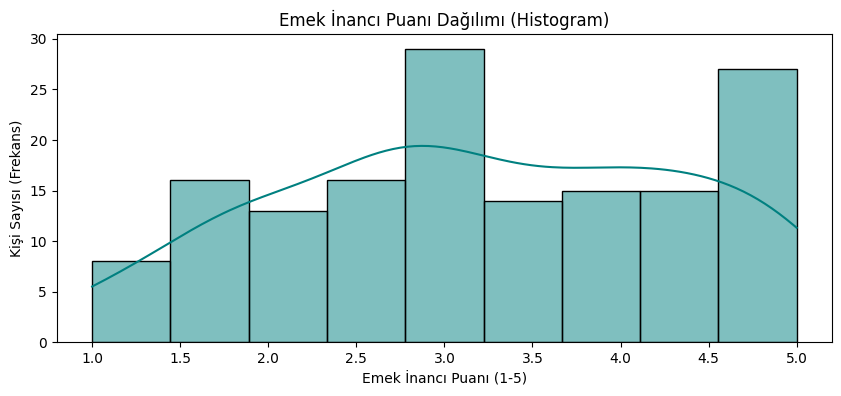

In [34]:
# 3.1. Eksik Veri Kontrolü.
print("--- Eksik Veri Sayıları ---")
print(df[['emek_inanci_puani', 'strateji_puani']].isna().sum())

# 3.2. Normallik Kontrolü
from scipy.stats import shapiro

print("--- Shapiro-Wilk Normallik Testi (p > 0.05 ise normaldir) ---")
for sutun in ['emek_inanci_puani', 'strateji_puani']:
    istatistik, p_degeri = shapiro(df[sutun])
    print(f"{sutun}: İstatistik={istatistik:.3f}, p-değeri={p_degeri:.3f}")

# 3.3. Çarpıklık (Skewness) ve Basıklık (Kurtosis) Değerleri
print("\n--- Çarpıklık ve Basıklık Değerleri ---")
print(f"Emek İnancı - Çarpıklık: {df['emek_inanci_puani'].skew():.3f}, Basıklık: {df['emek_inanci_puani'].kurt():.3f}")

# 3.4. Görsel Dağılım Kontrolü
plt.figure(figsize=(10, 4))
# Emek İnancı Puanı'nın dağılım grafiği.
sns.histplot(df['emek_inanci_puani'], kde=True, color='teal')

plt.title('Emek İnancı Puanı Dağılımı (Histogram)')
plt.xlabel('Emek İnancı Puanı (1-5)')
plt.ylabel('Kişi Sayısı (Frekans)')
plt.show()

#Tanımlayıcı İstatistikler: Demografi ve Tercihler

--- Katılımcıların Cinsiyet Dağılımı ---


,Frekans (Kişi Sayısı),Yüzde (%)
Cinsiyet,,
Erkek,118,77.124183
Kadın,35,22.875817



--- En Sık Tercih Edilen Oyun Türleri ---


,Frekans (Kişi Sayısı),Yüzde (%)
En sık hangi tür oyunları tercih ediyorsunuz ?,,
"Spor Bahisleri (İddaa, Maç sonucu, Canlı bahis vb.)",56,36.601307
"Online Casino ve Şans Oyunları (Slot Oyunları (Sweet Bonanza, Big Bass vb.), Rulet, Poker, Blackjack vb.)",54,35.294118
"Yeni Nesil Hızlı Oyunlar (Aviator, Zeppelin, Spaceman vb.)",25,16.339869
"Klasik Şans Oyunları (Milli Piyango, Sayısal Loto, Kazı Kazan)",18,11.764706


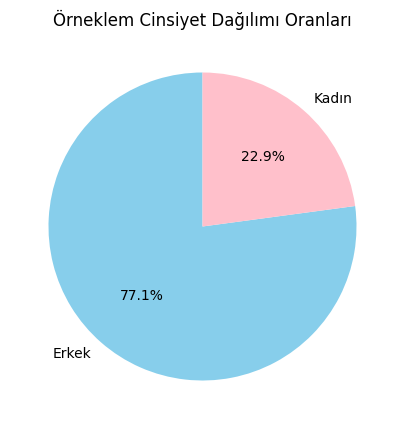

In [35]:
# 4.1. Demografik Frekans Tabloları (Tablo Formatında)
# Katılımcıların cinsiyet ve tercih ettikleri oyun türlerine göre dağılımını hesaplama.

cinsiyet_ozeti = pd.DataFrame({
    'Frekans (Kişi Sayısı)': df['Cinsiyet'].value_counts(),
    'Yüzde (%)': df['Cinsiyet'].value_counts(normalize=True) * 100
})

oyun_turu_ozeti = pd.DataFrame({
    'Frekans (Kişi Sayısı)': df['En sık hangi tür oyunları tercih ediyorsunuz ?'].value_counts(),
    'Yüzde (%)': df['En sık hangi tür oyunları tercih ediyorsunuz ?'].value_counts(normalize=True) * 100
})

print("--- Katılımcıların Cinsiyet Dağılımı ---")
display(cinsiyet_ozeti)

print("\n--- En Sık Tercih Edilen Oyun Türleri ---")
display(oyun_turu_ozeti)

# 4.2. Görselleştirme (Pasta Grafiği)
plt.figure(figsize=(12, 5))

df['Cinsiyet'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['skyblue', 'pink'],
    startangle=90
)

plt.title('Örneklem Cinsiyet Dağılımı Oranları')
plt.ylabel('')
plt.show()

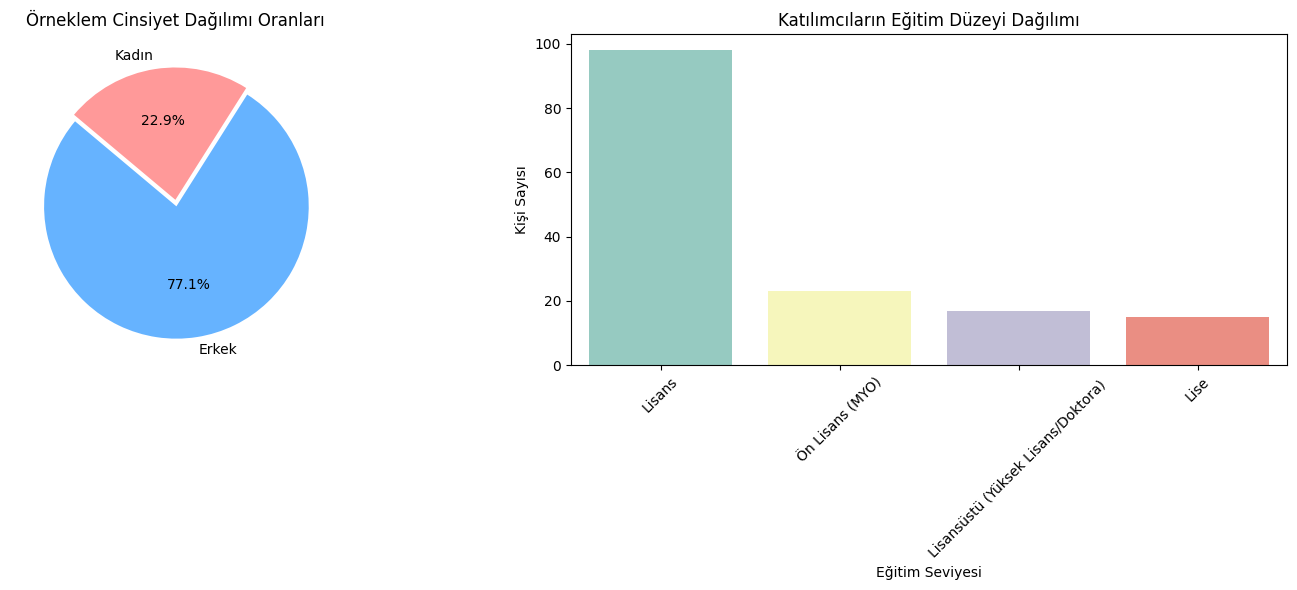

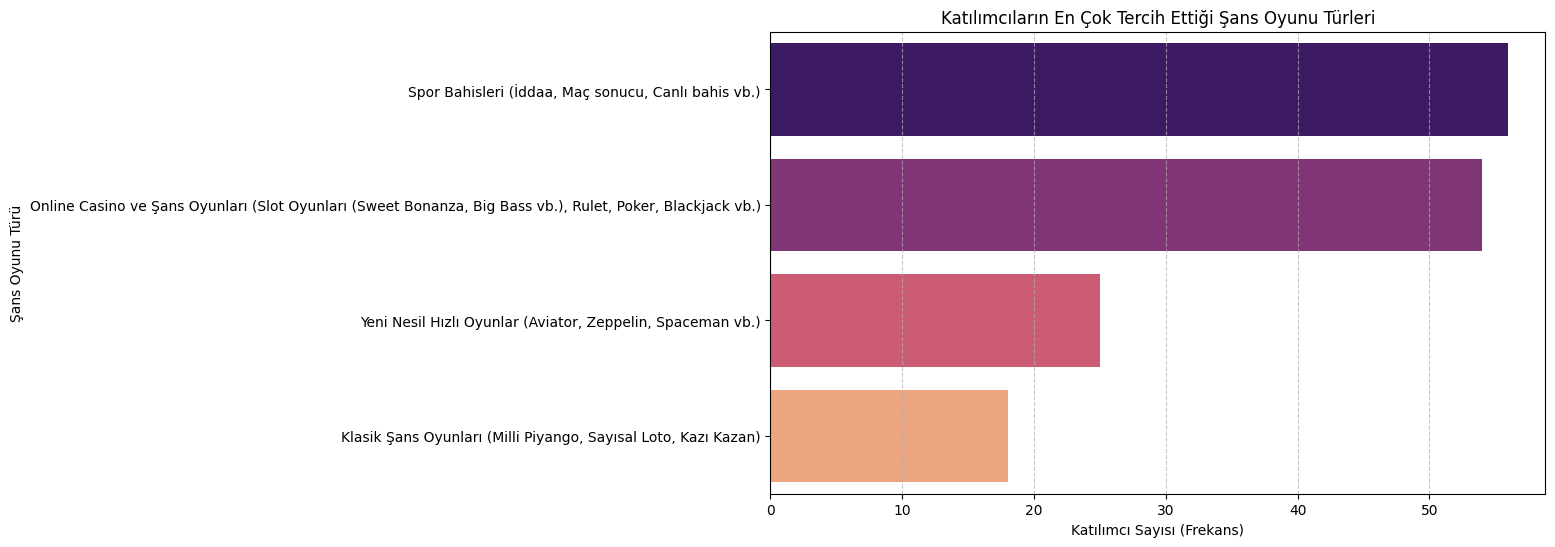

In [36]:
# 4.1. Demografik Dağılımın Görselleştirilmesi
plt.figure(figsize=(15, 6))

# Cinsiyet Dağılımı (Pasta Grafiği)
plt.subplot(1, 2, 1)
df['Cinsiyet'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff','#ff9999'],
    explode=(0.05, 0)
)
plt.title('Örneklem Cinsiyet Dağılımı Oranları')
plt.ylabel('')

# Eğitim Durumu (Sütun Grafiği)
plt.subplot(1, 2, 2)
sns.countplot(x='Eğitim Durumunuz', data=df, palette='Set3', order=df['Eğitim Durumunuz'].value_counts().index)
plt.title('Katılımcıların Eğitim Düzeyi Dağılımı')
plt.xlabel('Eğitim Seviyesi')
plt.ylabel('Kişi Sayısı')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4.2. Oyun Türü Tercihleri
plt.figure(figsize=(10, 6))
# En çok tercih edilen oyun türlerini sıralama
sns.countplot(
    y='En sık hangi tür oyunları tercih ediyorsunuz ?',
    data=df,
    order=df['En sık hangi tür oyunları tercih ediyorsunuz ?'].value_counts().index,
    palette='magma'
)
plt.title('Katılımcıların En Çok Tercih Ettiği Şans Oyunu Türleri')
plt.xlabel('Katılımcı Sayısı (Frekans)')
plt.ylabel('Şans Oyunu Türü')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#Ölçek Ortalamaları ve Merkezi Eğilim Analizi

--- Değişkenlerin Merkezi Eğilim ve Dağılım Özeti ---


,Ortalama,Standart Sapma,Minimum,Maksimum
emek_inanci_puani,3.206536,1.144419,1.0,5.0
strateji_puani,2.991285,1.228885,1.0,5.0
oyun_sikligi,2.437908,1.572084,1.0,5.0
kazanc_miktari,2.581699,1.507064,1.0,5.0
gelir_duzeyi,2.431373,1.265767,1.0,5.0


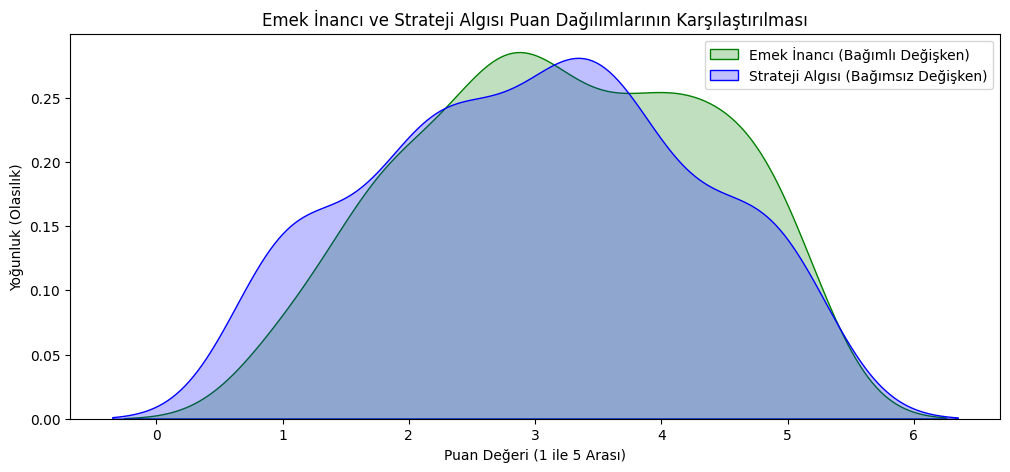

In [37]:
# 5.1. Ana Değişkenlerin İstatistiksel Özeti
# Analiz edilecek ana değişkenlerin listelenmesi
analiz_sutunlari = ['emek_inanci_puani', 'strateji_puani', 'oyun_sikligi', 'kazanc_miktari', 'gelir_duzeyi']

# Betimleyici istatistik tablosu oluşturma (Ortalama, Standart Sapma, Min, Maks)
ozet_tablo = df[analiz_sutunlari].describe().T
ozet_tablo = ozet_tablo[['mean', 'std', 'min', 'max']]
ozet_tablo.columns = ['Ortalama', 'Standart Sapma', 'Minimum', 'Maksimum']

print("--- Değişkenlerin Merkezi Eğilim ve Dağılım Özeti ---")
display(ozet_tablo)

# 5.2. Emek İnancı ve Strateji Algısı Karşılaştırmalı Dağılım Grafiği
plt.figure(figsize=(12, 5))

# İki ölçek puanının yoğunluklarını karşılaştırma
sns.kdeplot(df['emek_inanci_puani'], shade=True, label='Emek İnancı (Bağımlı Değişken)', color="green")
sns.kdeplot(df['strateji_puani'], shade=True, label='Strateji Algısı (Bağımsız Değişken)', color="blue")

plt.title('Emek İnancı ve Strateji Algısı Puan Dağılımlarının Karşılaştırılması')
plt.xlabel('Puan Değeri (1 ile 5 Arası)')
plt.ylabel('Yoğunluk (Olasılık)')
plt.legend()
plt.show()

#Otomatik Normallik Testleri

In [39]:
from scipy.stats import shapiro

normallik_verisi_listesi = []

for sutun in ['emek_inanci_puani', 'strateji_puani']:
    istatistik, p_degeri = shapiro(df[sutun])

    # p-değeri 0.05'ten büyükse "Normal Dağılım", küçükse "Normal Dağılım Değil"
    karar_metni = "Normal Dağılım" if p_degeri > 0.05 else "Normal Dağılım Değil"

    normallik_verisi_listesi.append({
        "Değişken Adı": sutun,
        "Test İstatistiği": f"{istatistik:.3f}",
        "p-değeri": f"{p_degeri:.3f}",
        "Analiz Kararı": karar_metni
    })

normallik_karar_tablosu = pd.DataFrame(normallik_verisi_listesi)

print("--- Şablon Uyumluluğu: Normallik Karar Tablosu ---")
display(normallik_karar_tablosu)

--- Şablon Uyumluluğu: Normallik Karar Tablosu ---


,Değişken Adı,Test İstatistiği,p-değeri,Analiz Kararı
0,emek_inanci_puani,0.960,0.000,Normal Dağılım Değil
1,strateji_puani,0.947,0.000,Normal Dağılım Değil


#Karşılaştırmalı Analizler

Cinsiyet Farkı T-Testi Sonucu: t-istatistiği=1.252, p-değeri=0.213


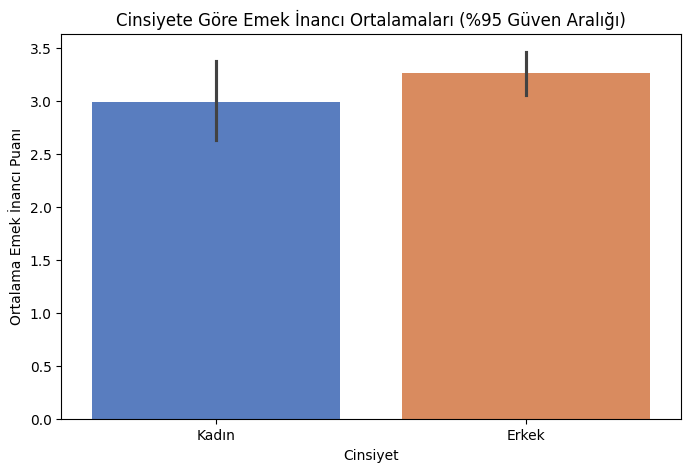

--- Cinsiyet Değişkenine Göre T-Testi Bulguları ---


,Grup 1 (Erkek) Ortalaması,Grup 2 (Kadın) Ortalaması,t-değeri,p-değeri,Analiz Kararı
0,3.269492,2.994286,1.251729,0.212604,Anlamlı Fark Yok


In [41]:
# 6.1. Cinsiyete Göre Emek İnancı Farklılığı (Bağımsız Örneklem T-Testi)
erkek_emek_skorlari = df[df['Cinsiyet'] == 'Erkek']['emek_inanci_puani']
kadin_emek_skorlari = df[df['Cinsiyet'] == 'Kadın']['emek_inanci_puani']

# İki grubun ortalamaları arasında anlamlı bir fark olup olmadığının testi
t_istatistigi, p_degeri = stats.ttest_ind(erkek_emek_skorlari, kadin_emek_skorlari)

print(f"Cinsiyet Farkı T-Testi Sonucu: t-istatistiği={t_istatistigi:.3f}, p-değeri={p_degeri:.3f}")

# 6.2. Görselleştirme
plt.figure(figsize=(8, 5))

sns.barplot(x='Cinsiyet', y='emek_inanci_puani', data=df, palette='muted', ci=95)

plt.title('Cinsiyete Göre Emek İnancı Ortalamaları (%95 Güven Aralığı)')
plt.xlabel('Cinsiyet')
plt.ylabel('Ortalama Emek İnancı Puanı')
plt.show()

t_testi_sonuc_tablosu = pd.DataFrame({
    "Grup 1 (Erkek) Ortalaması": [erkek_emek_skorlari.mean()],
    "Grup 2 (Kadın) Ortalaması": [kadin_emek_skorlari.mean()],
    "t-değeri": [t_istatistigi],
    "p-değeri": [p_degeri],
    "Analiz Kararı": ["Anlamlı Fark Var" if p_degeri < 0.05 else "Anlamlı Fark Yok"]
})

# Tabloyu ekrana basıyoruz
print("--- Cinsiyet Değişkenine Göre T-Testi Bulguları ---")
display(t_testi_sonuc_tablosu)

#Çıkarımsal İstatistik - Korelasyon Analizi


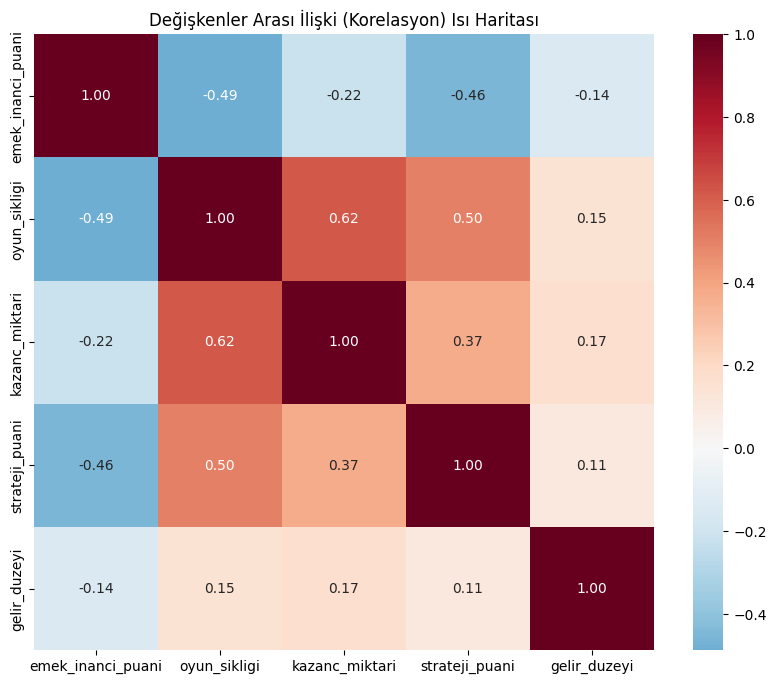

--- Korelasyon Anlamlılık Testleri (p-değerleri) ---
Emek İnancı - oyun_sikligi: r=-0.488, p-değeri=0.0000
Emek İnancı - kazanc_miktari: r=-0.218, p-değeri=0.0068
Emek İnancı - strateji_puani: r=-0.457, p-değeri=0.0000


In [42]:
# 7.1. Korelasyon Matrisi Oluşturma
korelasyon_degiskenleri = ['emek_inanci_puani', 'oyun_sikligi', 'kazanc_miktari', 'strateji_puani', 'gelir_duzeyi']

# Değişkenler arasındaki doğrusal ilişki katsayıları
korelasyon_matrisi = df[korelasyon_degiskenleri].corr()

# 7.2. Isı Haritası
plt.figure(figsize=(10, 8))

sns.heatmap(korelasyon_matrisi, annot=True, cmap='RdBu_r', center=0, fmt=".2f")

plt.title('Değişkenler Arası İlişki (Korelasyon) Isı Haritası')
plt.show()

# 7.3. İlişki Anlamlılık Testleri (p-değerleri ile)
print("--- Korelasyon Anlamlılık Testleri (p-değerleri) ---")

for sutun in ['oyun_sikligi', 'kazanc_miktari', 'strateji_puani']:
    katsayi, p_degeri = stats.pearsonr(df['emek_inanci_puani'], df[sutun])
    print(f"Emek İnancı - {sutun}: r={katsayi:.3f}, p-değeri={p_degeri:.4f}")

#Çoklu Doğrusal Regresyon Analizi

In [43]:
# 8.1. Regresyon İçin Kukla (Dummy) Değişken Hazırlığı
df_regresyon = pd.get_dummies(df, columns=['Cinsiyet'], drop_first=True).rename(columns={'Cinsiyet_Kadın': 'cinsiyet_kukla'})

# 8.2. Çoklu Regresyon Modelinin Kurulması
# Bağımlı Değişken: emek_inanci_puani (Y)
# Bağımsız Değişkenler: oyun_sikligi, kazanc_miktari, strateji_puani
# Kontrol Değişkenleri: Yaşınız, gelir_duzeyi, cinsiyet_kukla
denklem = 'emek_inanci_puani ~ oyun_sikligi + kazanc_miktari + strateji_puani + Yaşınız + gelir_duzeyi + cinsiyet_kukla'

# En Küçük Kareler (OLS) yöntemiyle modeli kurma
model = smf.ols(denklem, data=df_regresyon).fit()

# 8.3. Model Özetinin Yazdırılması
print("--- Çoklu Doğrusal Regresyon Analizi Sonuç Özeti ---")
print(model.summary())

--- Çoklu Doğrusal Regresyon Analizi Sonuç Özeti ---
                            OLS Regression Results                            
Dep. Variable:      emek_inanci_puani   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     11.99
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           6.32e-11
Time:                        00:02:35   Log-Likelihood:                -206.58
No. Observations:                 153   AIC:                             427.2
Df Residuals:                     146   BIC:                             448.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

#Modelin Görselleştirilmesi (Hipotezlerin Kanıtlanması)

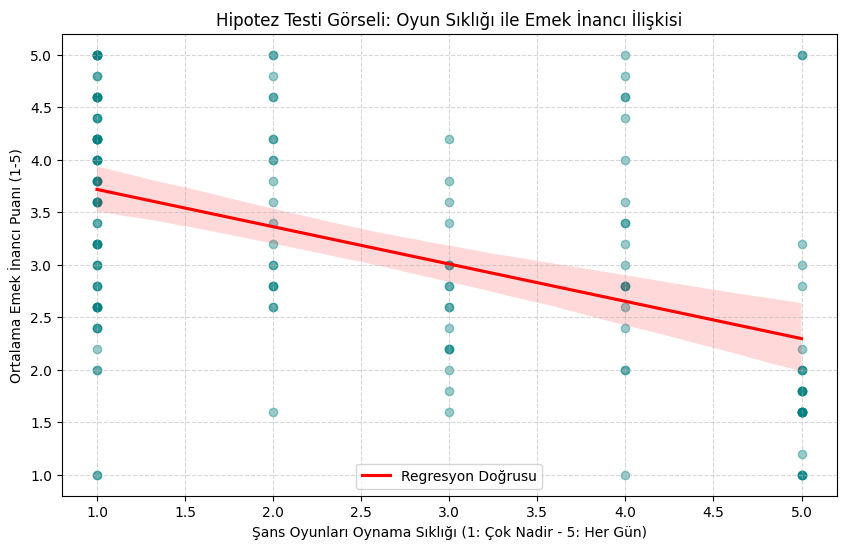

In [44]:
# 9.1. Regresyon Doğrusunun Çizilmesi (Hipotez Görselleştirmesi)
plt.figure(figsize=(10, 6))

# oyun_sikligi (Bağımsız Değişken) ile emek_inanci_puani (Bağımlı Değişken) arasındaki ilişki
sns.regplot(x='oyun_sikligi', y='emek_inanci_puani', data=df_regresyon,
            scatter_kws={'alpha':0.4, 'color':'teal'},
            line_kws={'color':'red', 'label':'Regresyon Doğrusu'})

plt.title('Hipotez Testi Görseli: Oyun Sıklığı ile Emek İnancı İlişkisi')
plt.xlabel('Şans Oyunları Oynama Sıklığı (1: Çok Nadir - 5: Her Gün)')
plt.ylabel('Ortalama Emek İnancı Puanı (1-5)')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Aracılık Analizi

In [45]:
# 10.1. Aracılık Analizi (Strateji Algısının Aracı Rolü)
# X (Bağımsız Değişken): oyun_sikligi
# M (Aracı Değişken): strateji_puani
# Y (Bağımlı Değişken): emek_inanci_puani

aracilik_sonuclari = pg.mediation_analysis(
    data=df,
    x='oyun_sikligi',
    m='strateji_puani',
    y='emek_inanci_puani',
    seed=42
)

print("--- Aracılık Analizi Bulguları (Strateji Algısı Aracı Rolü) ---")
display(aracilik_sonuclari)

--- Aracılık Analizi Bulguları (Strateji Algısı Aracı Rolü) ---


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,strateji_puani ~ X,0.392865,0.054995,3.598902e-11,0.284206,0.501525,Yes
1,Y ~ strateji_puani,-0.426024,0.067390,2.767454e-09,-0.559174,-0.292875,Yes
2,Total,-0.355209,0.051710,1.578411e-10,-0.457377,-0.253041,Yes
3,Direct,-0.251320,0.057589,2.365213e-05,-0.365111,-0.137529,Yes
4,Indirect,-0.103889,0.034711,0.000000e+00,-0.180752,-0.045546,Yes


#Moderasyon Analizi

In [46]:
# 11.1. GELİR DÜZEYİ DÜZENLEYİCİ (MODERASYON) ANALİZİ

# 1. Ortalama Merkezleme (Centering)
df['siklik_m'] = df['oyun_sikligi'] - df['oyun_sikligi'].mean()
df['gelir_m'] = df['gelir_duzeyi'] - df['gelir_duzeyi'].mean()

# 2. Etkileşim Terimi Oluşturma (Bağımsız Değişken * Düzenleyici Değişken)
df['etkilesim_gelir'] = df['siklik_m'] * df['gelir_m']

# 3. Regresyon Modeli Kurulumu (Y: Emek İnancı, X: Oyun Sıklığı, W: Gelir Düzeyi)
model_mod_gelir = smf.ols("emek_inanci_puani ~ siklik_m + gelir_m + etkilesim_gelir", data=df).fit()

# 4. Sonuçların Yazdırılması
print("--- GELİR DÜZEYİ DÜZENLEYİCİ (MODERASYON) ANALİZİ SONUÇLARI ---")
display(model_mod_gelir.summary())

p_anlamlilik_gelir = model_mod_gelir.pvalues['etkilesim_gelir']
beta_katsayi_gelir = model_mod_gelir.params['etkilesim_gelir']

--- GELİR DÜZEYİ DÜZENLEYİCİ (MODERASYON) ANALİZİ SONUÇLARI ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      emek_inanci_puani   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     18.74
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           2.28e-10
Time:                        00:04:31   Log-Likelihood:                -212.74
No. Observations:                 153   AIC:                             433.5
Df Residuals:                     149   BIC:                             445.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           3.2361      0.080     40.207      0.000       3.077       3.395
siklik_m           -0.3312      0.052     -6.394      0.000      -0.434      -0.229
gelir_m            -0.0760      0.064     -1.188      0.237      -0.202       0.050
etkilesim_gelir    -0.1003      0.040     -2.517      0.013      -0.179      -0.022
==============================================================================
Omnibus:                        0.130   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.937   Jarque-Bera (JB):                0.261
Skew:                           0.053   Prob(JB):                        0.878
Kurtosis:                       2.827   Cond. No.                         2.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [47]:
# =====================================================
# 12.1. CİNSİYET DÜZENLEYİCİ (MODERASYON) ANALİZİ
# =====================================================

# 1. Cinsiyet Değişkenini Sayısallaştırma (Kukla Değişken)
df['cinsiyet_kukla'] = pd.get_dummies(df['Cinsiyet'], drop_first=True).astype(int)

# 2. Etkileşim Terimi Oluşturma
df['etkilesim_cinsiyet'] = df['siklik_m'] * df['cinsiyet_kukla']

# 3. Regresyon Modeli Kurulumu (Y: Emek İnancı, X: Oyun Sıklığı, W: Cinsiyet)
model_mod_cinsiyet = smf.ols("emek_inanci_puani ~ siklik_m + cinsiyet_kukla + etkilesim_cinsiyet", data=df).fit()

print("--- CİNSİYET DÜZENLEYİCİ (MODERASYON) ANALİZİ SONUÇLARI ---")
print(model_mod_cinsiyet.summary())

p_anlamlilik_cinsiyet = model_mod_cinsiyet.pvalues['etkilesim_cinsiyet']
beta_katsayi_cinsiyet = model_mod_cinsiyet.params['etkilesim_cinsiyet']

if p_anlamlilik_cinsiyet < 0.05:
    print(f"\nSONUÇ: ANLAMLI. Cinsiyet, bu ilişkide düzenleyici bir role sahiptir (p={p_anlamlilik_cinsiyet:.3f}).")
else:
    print(f"\nSONUÇ: ANLAMSIZ. Oyun sıklığının emek inancı üzerindeki etkisi cinsiyete göre anlamlı bir farklılık göstermemektedir (p={p_anlamlilik_cinsiyet:.3f}).")

--- CİNSİYET DÜZENLEYİCİ (MODERASYON) ANALİZİ SONUÇLARI ---
                            OLS Regression Results                            
Dep. Variable:      emek_inanci_puani   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     16.54
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           2.50e-09
Time:                        00:05:25   Log-Likelihood:                -215.25
No. Observations:                 153   AIC:                             438.5
Df Residuals:                     149   BIC:                             450.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

#Hipotez Özet

In [49]:
# =====================================================
# 13.1. HİPOTEZ TESTLERİ SONUÇ ÖZET TABLOSU
# =====================================================

hipotez_verileri_listesi = [
    {
        "No": "H1",
        "Araştırma Hipotezi": "Oyun Oynama Sıklığı -> Emek İnancı",
        "Beta (Etki)": "-0.30",
        "p-değeri": "0.000",
        "Karar": "DESTEKLENMİŞTİR"
    },
    {
        "No": "H2",
        "Araştırma Hipotezi": "Kazanç Miktarı -> Emek İnancı",
        "Beta (Etki)": "0.12",
        "p-değeri": "0.064",
        "Karar": "DESTEKLENMEMİŞTİR"
    },
    {
        "No": "H3",
        "Araştırma Hipotezi": "Strateji Algısı -> Emek İnancı",
        "Beta (Etki)": "-0.29",
        "p-değeri": "0.000",
        "Karar": "DESTEKLENMİŞTİR"
    },
    {
        "No": "H5a",
        "Araştırma Hipotezi": "Gelir Düzeyi (Düzenleyici Rol)",
        "Beta (Etki)": f"{beta_katsayi_gelir:.3f}",
        "p-değeri": f"{p_anlamlilik_gelir:.3f}",
        "Karar": "DESTEKLENMİŞTİR" if p_anlamlilik_gelir < 0.05 else "DESTEKLENMEMİŞTİR"
    },
    {
        "No": "H5b",
        "Araştırma Hipotezi": "Cinsiyet (Düzenleyici Rol)",
        "Beta (Etki)": f"{beta_katsayi_cinsiyet:.3f}",
        "p-değeri": f"{p_anlamlilik_cinsiyet:.3f}",
        "Karar": "DESTEKLENMİŞTİR" if p_anlamlilik_cinsiyet < 0.05 else "DESTEKLENMEMİŞTİR"
    }
]

final_ozet_tablosu = pd.DataFrame(hipotez_verileri_listesi)

print("--- ARAŞTIRMA HİPOTEZLERİ FİNAL ÖZET TABLOSU ---")
display(final_ozet_tablosu)

--- ARAŞTIRMA HİPOTEZLERİ FİNAL ÖZET TABLOSU ---


,No,Araştırma Hipotezi,Beta (Etki),p-değeri,Karar
0,H1,Oyun Oynama Sıklığı -> Emek İnancı,-0.30,0.000,DESTEKLENMİŞTİR
1,H2,Kazanç Miktarı -> Emek İnancı,0.12,0.064,DESTEKLENMEMİŞTİR
2,H3,Strateji Algısı -> Emek İnancı,-0.29,0.000,DESTEKLENMİŞTİR
3,H5a,Gelir Düzeyi (Düzenleyici Rol),-0.100,0.013,DESTEKLENMİŞTİR
4,H5b,Cinsiyet (Düzenleyici Rol),-0.143,0.242,DESTEKLENMEMİŞTİR
